# 4-2. LangGraph Basic RAG

## 학습 목표

- Naive RAG 코드를 LangGraph 구조로 바꾼다.
- 검색 노드와 답변 생성 노드를 분리한다.


## 공통 전제

- 실습 데이터: `../data/공직자_민원응대_핵심_매뉴얼.pdf`
- 기본 모델: `gpt-4o-mini`
- 기본 임베딩 모델: `text-embedding-3-small`
- 벡터DB: Qdrant 로컬 인메모리 모드

> 이 노트북은 `src` 파일을 import하지 않고, 노트북 안의 코드만으로 실행되도록 구성한다.


In [1]:
from dotenv import load_dotenv

load_dotenv(override=True, dotenv_path="../../.env")

False

## 1. 문서 준비 완료


## 2. 프롬프트와 유틸 함수


In [2]:
from langchain_openai import OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from const.const import create_model, create_embedding

QDRANT_URL = "http://localhost:6333"
COLLECTION_NAME = "civil_complaint_manual_medium"

EMBEDDING_MODEL = "text-embedding-3-small"

embeddings = create_embedding()

vector_store = QdrantVectorStore.from_existing_collection(
    embedding=embeddings,
    collection_name=COLLECTION_NAME,
    url=QDRANT_URL,
)

/Users/parkchanryong/Desktop/SKN_35/llm_workspace/.venv/lib/python3.12/site-packages/langchain_nvidia_ai_endpoints/_common.py:250: UserWarning: Found nvidia/nemotron-3-embed-1b in available_models, but type is unknown and inference may fail.
  warnings.warn(


In [3]:
from typing_extensions import TypedDict
from langchain_core.documents import Document
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser


def format_docs(docs: list[Document]) -> str:
    return "\n\n".join(
        [
            f"[근거 {i}] page={doc.metadata.get('page')}, chunk={doc.metadata.get('chunk_id')}\n{doc.page_content}"
            for i, doc in enumerate(docs, start=1)
        ]
    )


rag_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
당신은 공직자 민원응대 매뉴얼 기반 업무지원 AI입니다.
제공된 근거를 바탕으로만 답변하세요. 질문에 대한 근거가 없으면 없다고 대답하세요.

답변 형식:
1. 핵심 대응
2. 단계별 조치
3. 안내 표현
4. 근거
5. 주의사항
""",
        ),
        (
            "human",
            """
질문:
{question}

근거 문단:
{context}
""",
        ),
    ]
)

llm = create_model()
rag_chain = rag_prompt | llm | StrOutputParser()

/Users/parkchanryong/Desktop/SKN_35/llm_workspace/.venv/lib/python3.12/site-packages/langchain_nvidia_ai_endpoints/_common.py:250: UserWarning: Found z-ai/glm-5.3-flash in available_models, but type is unknown and inference may fail.
  warnings.warn(


## 3. State 정의


In [4]:
class RAGState(TypedDict):
    question: str  # 사용자 질문 (입력)
    documents: list[Document]  # 검색된 청크 목록
    context: str  # format_docs() 결과 (프롬프트용)
    answer: str  # LLM이 생성한 최종 답변 (출력)


## 4. Node 정의


In [5]:
from langgraph.graph import StateGraph, START, END


# ── retrieve 노드 ──────────────────────────────────────
def retrieve_node(state: RAGState) -> dict:
    question = state["question"]
    docs = vector_store.similarity_search(question, k=4)
    context = format_docs(docs)

    return {"documents": docs, "context": context}


# ── generate 노드 ──────────────────────────────────────
def generate_node(state: RAGState) -> dict:
    answer = rag_chain.invoke(
        {"question": state["question"], "context": state["context"]}
    )

    return {"answer": answer}

## 5. Graph 구성


In [6]:
# 빌더 생성
graph = StateGraph(RAGState)

# 노드 등록
graph.add_node("retrieve", retrieve_node)
graph.add_node("generate", generate_node)

# 엣지 연결
graph.add_edge(START, "retrieve")
graph.add_edge("retrieve", "generate")
graph.add_edge("generate", END)

# 컴파일
app = graph.compile()


### 그래프 시각화


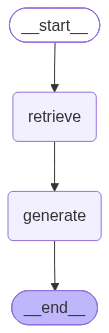

In [7]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

## 6. 실행


In [8]:
result = app.invoke(
    {"question": "민원인이 기관장과 통화하겠다고 요구하면 어떻게 대응해야 하나요?"}
)

print(result["answer"])

# 기관장(상급자) 통화 요구 시 대응 방안

## 1. 핵심 대응
**민원인 요구에 끌려가지 말고, 기관 입장을 설명하며 담당자로서 응대**

## 2. 단계별 조치
1. **담당자 권한 설명**: 위임규정에 따른 업무분장과 담당자의 역할을 설명하며, 자신이 기관장으로부터 민원처리권한을 위임받은 담당자임을 안내
2. **민원사항 확인 유도**: 도와드릴 수 있는 방법을 찾아보겠다고 안내하고, 차분하게 민원사항을 말씀해주시기 요청
3. **통화 요구 사유 파악**: 상급자와 통화하고 싶은 정확한 이유를 확인 (해결하고 싶은 정확한 민원이 있는지, 아니면 단순히 상급자와 통화를 원하는 것인지)
4. **갈등 발생 시**: 상담 중 마찰 또는 갈등이 발생할 우려가 있는 경우에는 부서장 또는 상급자가 적극 개입하여 민원인을 진정시키고 갈등을 해소

## 3. 안내 표현
> "선생님 말씀하신 민원은 제가 저희 기관 기관장으로부터 민원처리권한을 위임받은 담당자입니다. 해당 업무의 담당자인 제가 말씀을 듣고 도와드릴 수 있는 방법을 찾아보겠습니다. 차분하게 민원사항을 말씀해주시기 바랍니다."

> "선생님, 상급자와 통화하고 싶은 이유가 정확히 어떤 이유 때문인지 여쭤봐도 되겠습니까?"

## 4. 근거
- 「현장공무원을 위한 민원응대 핵심매뉴얼」 p.7, 2-3 상급자(기관장 등) 통화 요구
- 「현장공무원을 위한 민원응대 핵심매뉴얼」 p.4 (갈등 발생 우려 시 부서장·상급자 개입, 질문과 요구에 적극적 해결 노력)

## 5. 주의사항
- **자신의 업무 범위만 내세워 소극적으로 대처하지 않음** (p.4)
- 무성의한 응대나 주관적·모호한 응대 주의 (p.4)
- 제공된 근거에는 통화 요구를 수용하거나 거부하는 구체적 기준이 명시되어 있지 않으므로, 위에 제시된 원칙(요구에 끌려가지 않고 기관 입장 설명)에 따라 상황을 판단하여 응대


## 핵심 정리

```text
START → retrieve → generate → END
```

- 기존 Naive RAG 코드를 검색 노드와 답변 생성 노드로 분리했다.
- 이것이 LangGraph Basic RAG의 기본 구조다.
- 다음 단계에서는 질문 분류, 근거 정리, 답변 검증을 추가해 Modular RAG로 확장한다.
